In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering,KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [4]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

# Display the first 5 rows of the DataFrame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


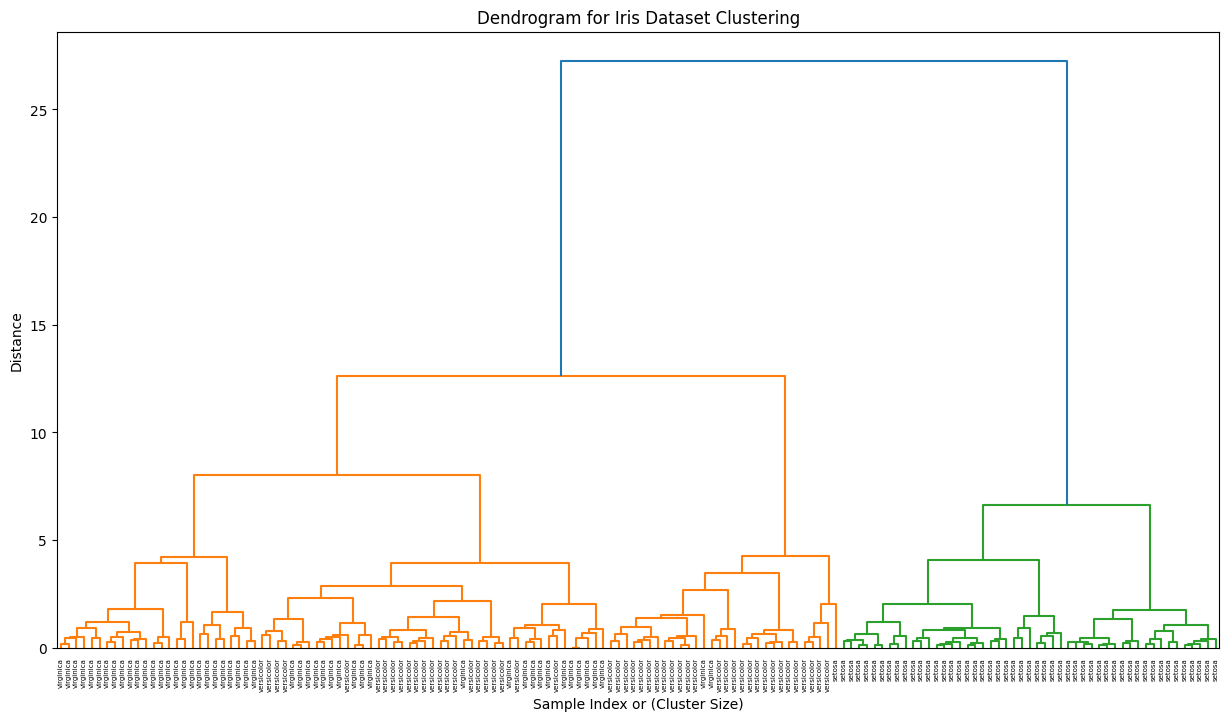

In [5]:

x = df.drop('species', axis=1)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
linked = linkage(x_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,orientation='top',labels=df['species'].values,distance_sort='descending',show_leaf_counts=True)
plt.title('Dendrogram for Iris Dataset Clustering')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.show()

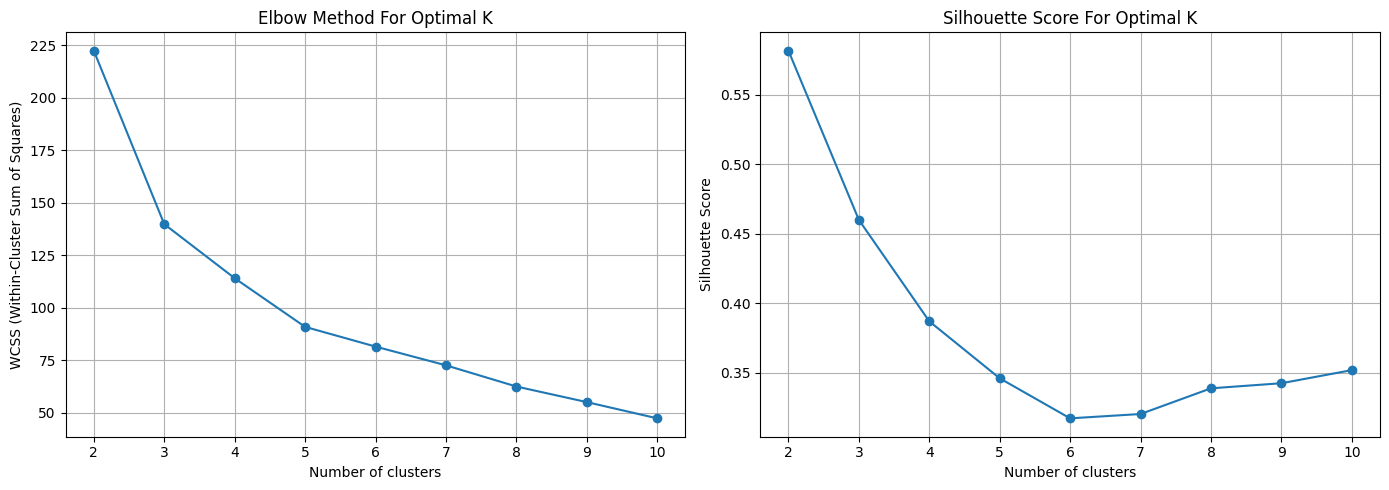

In [6]:
wcss = []
silhouette_avg = []

# Define a range of k values to try
# It's good practice to start from k=2 for silhouette score
range_n_clusters = range(2, 11)

for num_clusters in range_n_clusters:
    # K-Means clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(x_scaled)

    # Elbow Method: Append WCSS
    wcss.append(kmeans.inertia_)

    # Silhouette Score: Calculate and append
    cluster_labels = kmeans.labels_
    silhouette_avg.append(silhouette_score(x_scaled, cluster_labels))

# Plotting the Elbow Method
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, wcss, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)

# Plotting the Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_avg, marker='o')
plt.title('Silhouette Score For Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
optimal_k_silhouette = range_n_clusters[np.argmax(silhouette_avg)]
max_silhouette_score = np.max(silhouette_avg)

print(f"Optimal K based on Silhouette Score: {optimal_k_silhouette} (Score: {max_silhouette_score:.3f})")

Optimal K based on Silhouette Score: 2 (Score: 0.582)


In [8]:
agglomerative = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Agglomerative_Cluster'] = agglomerative.fit_predict(x_scaled)
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,Agglomerative_Cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [9]:

silhouette_agg = silhouette_score(x_scaled, df['Agglomerative_Cluster'])
print(f"Silhouette Score for Agglomerative Clustering (with 3 clusters): {silhouette_agg:.3f}")

davies_bouldin_agg = davies_bouldin_score(x_scaled, df['Agglomerative_Cluster'])
print(f"Davies-Bouldin Score for Agglomerative Clustering (with 3 clusters): {davies_bouldin_agg:.3f}")

Silhouette Score for Agglomerative Clustering (with 3 clusters): 0.447
Davies-Bouldin Score for Agglomerative Clustering (with 3 clusters): 0.803


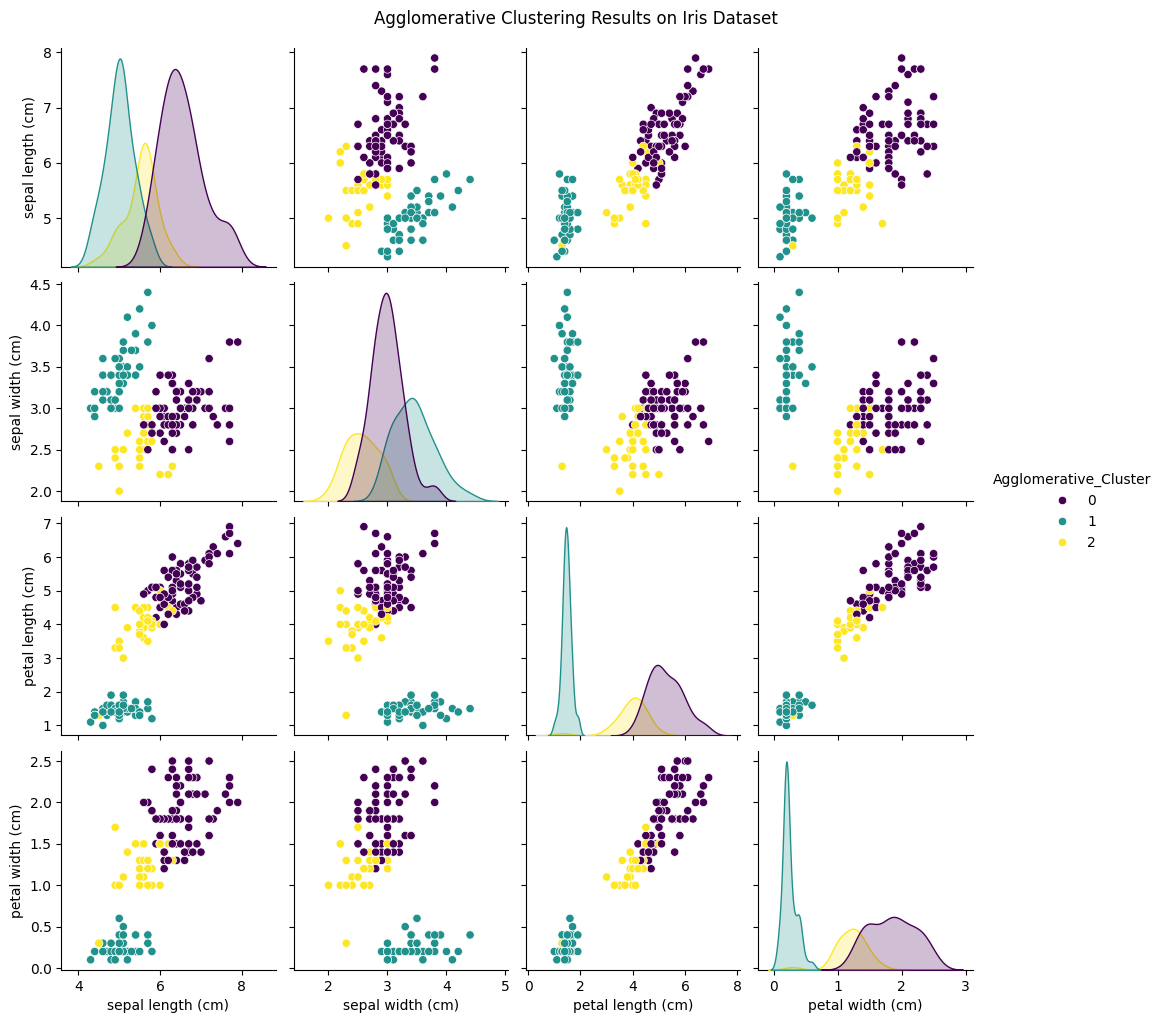

In [10]:
# Visualize the clusters with pairplot
sns.pairplot(df.drop('species', axis=1), hue='Agglomerative_Cluster', palette='viridis')
plt.suptitle('Agglomerative Clustering Results on Iris Dataset', y=1.02) # Add a title for the whole plot
plt.show()

In [11]:
linkage_methods = ['ward', 'complete', 'average', 'single']
silhouette_scores_linkage = {}

print('Silhouette Scores for Agglomerative Clustering with different linkage methods:')
for method in linkage_methods:
    try:
        # Apply Agglomerative Clustering with 3 clusters (as determined previously)
        agglomerative_linkage = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage=method)
        # Fit and predict clusters
        cluster_labels_linkage = agglomerative_linkage.fit_predict(x_scaled)

        score = silhouette_score(x_scaled, cluster_labels_linkage)
        silhouette_scores_linkage[method] = score
        print(f"  - {method.capitalize()} linkage: {score:.3f}")
    except Exception as e:
        print(f"  - Error with {method.capitalize()} linkage: {e}")
        silhouette_scores_linkage[method] = None
best_method = max(silhouette_scores_linkage, key=silhouette_scores_linkage.get)
print(f"\nThe best linkage method based on Silhouette Score is: {best_method.capitalize()} (Score: {silhouette_scores_linkage[best_method]:.3f})")

Silhouette Scores for Agglomerative Clustering with different linkage methods:
  - Ward linkage: 0.447
  - Complete linkage: 0.450
  - Average linkage: 0.480
  - Single linkage: 0.505

The best linkage method based on Silhouette Score is: Single (Score: 0.505)
